In [33]:
import numpy as np
import pandas as pd

In [34]:
df = pd.read_csv('spam.csv', encoding='latin1')
df.sample(10)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
2299,spam,Congrats! 1 year special cinema pass for 2 is ...,NaN,NaN,NaN
3846,spam,Fantasy Football is back on your TV. Go to Sky...,NaN,NaN,NaN
766,ham,"I'm nt goin, got somethin on, unless they meet...",NaN,NaN,NaN
5054,ham,Am on a train back from northampton so i'm afr...,NaN,NaN,NaN
1990,ham,HI DARLIN IVE JUST GOT BACK AND I HAD A REALLY...,NaN,NaN,NaN
1826,ham,Dude. What's up. How Teresa. Hope you have bee...,NaN,NaN,NaN
1609,ham,You all ready for * big day tomorrow?,NaN,NaN,NaN
1516,ham,I need to come home and give you some good lov...,NaN,NaN,NaN
1085,ham,FR'NDSHIP is like a needle of a clock. Though ...,NaN,NaN,NaN
3773,ham,Ok... But bag again..,NaN,NaN,NaN


In [16]:
df.shape

(5572, 5)

#1. Data Cleaning
#2. EDA (Exploratory Data Analysis)
3. Text Preprocessing
4. Model Building
5. Evaluation
6. Improvement
7. Website
8. Deployment

## 1. DATA CLEANING 

In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   target          5572 non-null   object
 1   Text            5572 non-null   object
 2   Unnamed: 2      50 non-null     object
 3   Unnamed: 3      12 non-null     object
 4   Unnamed: 4      6 non-null      object
 5   num_characters  5572 non-null   int64 
dtypes: int64(1), object(5)
memory usage: 261.3+ KB


In [51]:
print(df.columns.tolist())

columns_to_drop = ['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4']

df.drop(columns=columns_to_drop, inplace=True, errors='ignore')

df.sample(10)

['target', 'Text', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'num_characters']


,target,Text,num_characters
1287,0,"What do you do, my dog ? Must I always wait ti...",138
2963,1,"Do you ever notice that when you're driving, a...",135
1743,0,I love to wine and dine my lady!,32
1172,0,Happy new years melody!,23
4702,0,Mmmmmmm *snuggles into you* ...*deep contented...,124
3939,0,Does daddy have a bb now.,25
5393,0,"All done, all handed in. Don't know if mega sh...",104
2997,0,No b4 Thursday,14
362,0,Check audrey's status right now,31
3342,0,"I haven't forgotten you, i might have a couple...",91


In [57]:
#renaming the columns
df.rename(columns={'v1': 'target', 'v2':'Text'}, inplace=True)
df.sample(10)

,target,Text,num_characters
1268,1,Can U get 2 phone NOW? I wanna chat 2 set up m...,147
387,0,Mm that time you dont like fun,30
3035,0,;-) ok. I feel like john lennon.,32
556,0,Having lunch:)you are not in online?why?,40
783,1,You have an important customer service announc...,99
4567,0,hiya hows it going in sunny africa? hope u r a...,112
218,0,I have to take exam with march 3,32
2032,0,"Yes, i'm small kid.. And boost is the secret o...",59
155,0,Aaooooright are you at work?,28
3342,0,"I haven't forgotten you, i might have a couple...",91


In [20]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

In [56]:
df['target'] = encoder.fit_transform(df['target'])
#converts all the ham msgs to 0 and spam to 1

In [54]:
 df.head() #shows the first 5 rows of your data

,target,Text,num_characters
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [46]:
#checking missing values
df.isnull().sum()

target               0
Text                 0
Unnamed: 2        5522
Unnamed: 3        5560
Unnamed: 4        5566
num_characters       0
dtype: int64

In [24]:
#check for any duplicates
df.duplicated().sum()

np.int64(403)

In [25]:
#remove duplicates
df.drop_duplicates(keep='first')
df.duplicated().sum()

np.int64(403)

In [30]:
df.shape

(5169, 2)

## 2. EDA

In [26]:
df['target'].value_counts()

target
0    4825
1     747
Name: count, dtype: int64

([<matplotlib.patches.Wedge at 0x1ff35cdd940>,
 [Text(-1.0038715425384215, 0.4497131597824666, 'ham'),
  Text(1.0038714746336121, -0.44971331136284726, 'spam')],
 [Text(-0.547566295930048, 0.24529808715407267, '86.59'),
  Text(0.5475662588910611, -0.24529816983428027, '13.41')])

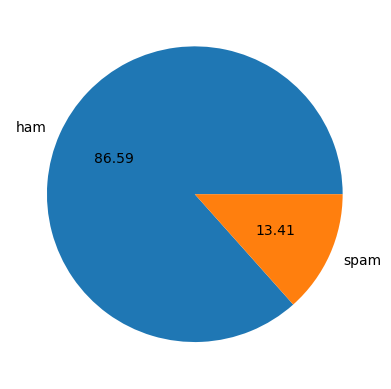

In [27]:
import matplotlib.pyplot as plt
plt.pie(df['target'].value_counts(), labels=['ham','spam'], autopct="%0.2f")

In [1]:
#Data is Imbalanced 

In [66]:
import nltk

In [28]:
!pip install nltk

Defaulting to user installation because normal site-packages is not writeable


In [64]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [58]:
df['num_characters']=df['Text'].apply(len)

In [59]:
df.head()

,target,Text,num_characters
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [71]:
import nltk
nltk.download('punkt_tab')  # Try downloading the specific resource mentioned in the error

#  number of words
df['num_words']=df['Text'].apply(lambda x: len(nltk.word_tokenize(x)))

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


df.head()

In [72]:
df.head()

,target,Text,num_characters,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [77]:
df['num_sentences']=df['Text'].apply(lambda x: len(nltk.sent_tokenize(x)))

In [78]:
df.head()

,target,Text,num_characters,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [79]:
df[['num_characters', 'num_words', 'num_sentences']].describe()

,num_characters,num_words,num_sentences
count,5572.000000,5572.000000,5572.000000
mean,80.118808,18.699390,1.996411
std,59.690841,13.741932,1.520159
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,61.000000,15.000000,1.500000
75%,121.000000,27.000000,2.000000
max,910.000000,220.000000,38.000000


In [85]:
#analysis of Ham messages
df[df['target']==0] [['num_characters', 'num_words', 'num_sentences']].describe()

,num_characters,num_words,num_sentences
count,4825.000000,4825.000000,4825.000000
mean,71.023627,17.276269,1.837720
std,58.016023,13.988585,1.454388
min,2.000000,1.000000,1.000000
25%,33.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,92.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [86]:
#analysis of spam messages
df[df['target']==1][['num_characters', 'num_words', 'num_sentences']].describe()

,num_characters,num_words,num_sentences
count,747.000000,747.000000,747.000000
mean,138.866131,27.891566,3.021419
std,29.183082,6.867007,1.537580
min,13.000000,2.000000,1.000000
25%,132.500000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


In [89]:
import seaborn as sns

In [88]:
!pip install seaborn

Defaulting to user installation because normal site-packages is not writeable


<Axes: xlabel='num_characters', ylabel='Count'>

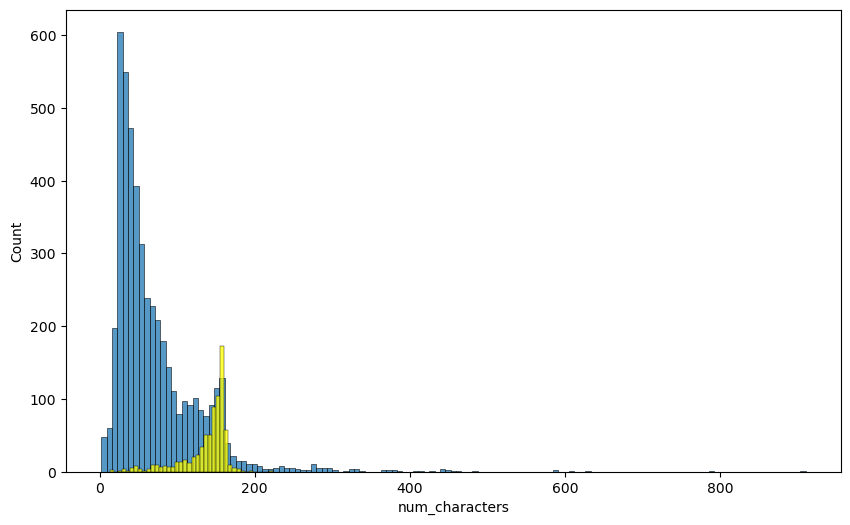

In [103]:
#drawing a histogram for number of characters for Ham and Spam messages
plt.figure(figsize=(10,6))
sns.histplot(df[df['target']==0]['num_characters']) #for Ham
sns.histplot(df[df['target']==1]['num_characters'],color='yellow') #for Spam

<Axes: xlabel='num_words', ylabel='Count'>

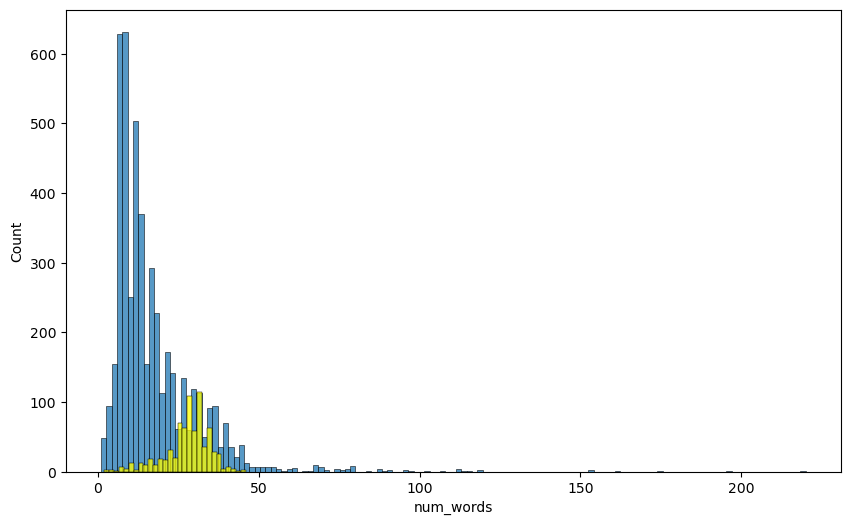

In [104]:
#drawing a histogram for number of words for Ham and Spam messages
plt.figure(figsize=(10,6))
sns.histplot(df[df['target']==0]['num_words']) #for Ham
sns.histplot(df[df['target']==1]['num_words'],color='yellow') #for Spam

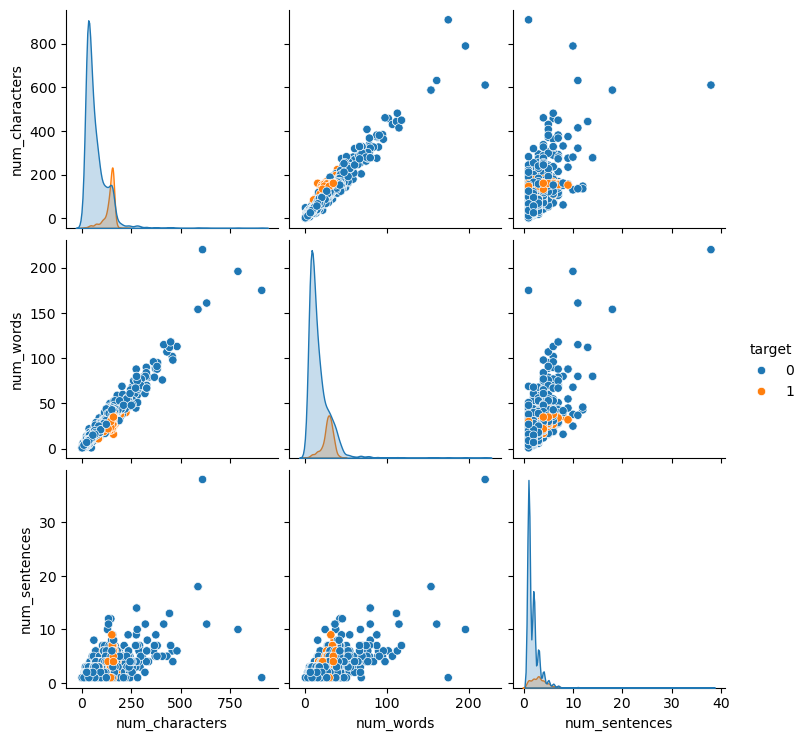

In [105]:
sns.pairplot(df,hue='target')

In [107]:
# First, identify which columns are numerical
numerical_columns = df.select_dtypes(include=['number']).columns

# Then calculate correlation only on numerical columns
correlation_matrix = df[numerical_columns].corr()

# Display the correlation matrix
correlation_matrix

# Alternatively, if you need to convert some text columns to numerical:
# For categorical data, you might use:
# df_encoded = pd.get_dummies(df, columns=['categorical_column_name'])
# df_encoded.corr()

,target,num_characters,num_words,num_sentences
target,1.000000,0.387285,0.263221,0.265332
num_characters,0.387285,1.000000,0.966310,0.631881
num_words,0.263221,0.966310,1.000000,0.685165
num_sentences,0.265332,0.631881,0.685165,1.000000


<Axes: >

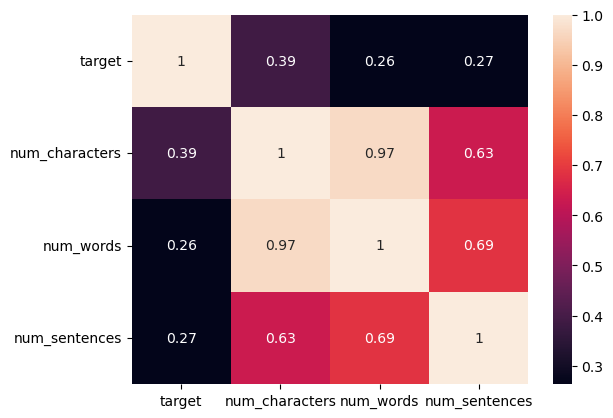

In [110]:
sns.heatmap(df[numerical_columns].corr(),annot=True)